# Claude-CLI routing-strategy comparison (exps 61-65)

Same load / dataset / users (96 users x 3 convs, CodeFlowBench, high-load replay); **only the routing strategy differs**, all at batch 32 / hold 600:

| exp | strategy | mode |
|---|---|---|
| 61 | none | - |
| 62 | prefix | - |
| 63 | affinity | hard |
| 64 | affinity | soft |
| 65 | both | hard |

Goal: pick the best prefix-cache routing strategy on KV-hit, stickiness, latency and throughput. Set `EXPERIMENTS_ROOT` and Run All.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import yaml
except Exception:
    yaml = None

# ---- config ----------------------------------------------------------------
EXPERIMENTS_ROOT = "/home/saeid/llm-la/src/client/experiments"
EXP_IDS = [61, 62, 63, 64, 65]
DELTAS = []           # [(baseline_exp, feature_exp), ...] ; [] to skip
RESULT_TIMEOUT_S = 1000.0   # router hard end-to-end ceiling (for timeout counting)

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 60)

def _read_json(p):
    p = Path(p)
    return json.load(p.open()) if p.is_file() else None

def _read_ndjson(p):
    p = Path(p); rows = []
    if not p.is_file():
        return rows
    with p.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                rows.append(json.loads(line))
            except Exception:
                pass
    return rows

def exp_dir(exp_id):
    return Path(EXPERIMENTS_ROOT) / str(exp_id)


## 1. Experiment registry

In [2]:
def load_meta(exp_id):
    m = {"exp": exp_id, "strategy": None, "mode": None, "hold_s": None, "batch": None,
         "total_convs": None, "wall_s": None, "load_s": None}
    cfgp = exp_dir(exp_id) / "config_used.yaml"
    if cfgp.is_file() and yaml is not None:
        try:
            cfg = yaml.safe_load(cfgp.open()) or {}
            h = cfg.get("helm", {}) or {}
            m["strategy"] = h.get("router_strategy")
            m["mode"] = h.get("router_affinity_mode")
            m["hold_s"] = h.get("router_affinity_hard_timeout_s")
            models = h.get("models") or []
            if models:
                m["batch"] = (models[0] or {}).get("batchSize")
        except Exception as e:
            print(f"[warn] exp {exp_id} config parse: {e}")
    rs = _read_json(exp_dir(exp_id) / "run_summary.json")
    if rs:
        m["wall_s"] = rs.get("wall_time_s")
        m["load_s"] = rs.get("load_runner_duration_s")
        u = rs.get("users") or {}
        if u:
            m["total_convs"] = (u.get("num_users") or 0) * (u.get("convs_per_user") or 0)
    return m

REG = pd.DataFrame([load_meta(e) for e in EXP_IDS]).set_index("exp")

def _label(exp):
    r = REG.loc[exp]
    strat = r["strategy"] or "?"
    mode = f"/{r['mode']}" if r["mode"] and strat in ("affinity", "both") else ""
    return f"{exp}:{strat}{mode} b{r['batch']} h{r['hold_s']}"

LABELS = {e: _label(e) for e in EXP_IDS}
REG["label"] = [LABELS[e] for e in REG.index]
REG

,strategy,mode,hold_s,batch,total_convs,wall_s,load_s,label
exp,,,,,,,,
61,none,hard,600,32,288,3386.653,3262.752,61:none b32 h600
62,prefix,hard,600,32,288,3452.624,3336.442,62:prefix b32 h600
63,affinity,hard,600,32,288,3595.999,3471.389,63:affinity/hard b32 h600
64,affinity,soft,600,32,288,3300.359,3171.101,64:affinity/soft b32 h600
65,both,hard,600,32,288,3184.381,3064.084,65:both/hard b32 h600


## 2. Logs analysis (per-request truth)

Every `logs.json` tagged by `exp`; conversation `group` + per-conversation turn occurrence (`occ`) so we can split single-turn vs multi-turn repeat turns.

In [3]:
KEEP = ["idx", "req_id", "conversation_id", "turn_idx", "num_turns",
        "affinity_key", "endpoint_id", "kv_hit", "kv_hits_len", "total_blocks",
        "matched_tokens", "ttft_s", "end_to_end_s", "model_latency_s",
        "prompt_tokens", "completion_tokens", "cache_read_input_tokens",
        "finish_reason", "send_failed", "t0_wall", "t1_wall"]

def load_logs(exp_id):
    rows = _read_ndjson(exp_dir(exp_id) / "logs.json")
    if not rows:
        return pd.DataFrame()
    df = pd.DataFrame(rows)
    for c in KEEP:
        if c not in df.columns:
            df[c] = np.nan
    df = df[KEEP].copy()
    df["exp"] = exp_id
    df["label"] = LABELS[exp_id]
    grp = df["conversation_id"].astype("object")
    grp = grp.where(grp.notna(), df["affinity_key"])
    grp = grp.where(grp.notna(), "req:" + df["req_id"].astype(str))
    df["group"] = grp.astype(str)
    for c in ["kv_hits_len", "total_blocks", "matched_tokens", "ttft_s",
              "end_to_end_s", "prompt_tokens", "completion_tokens",
              "cache_read_input_tokens", "t0_wall", "t1_wall"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df["kv_hit"] = df["kv_hit"].map(lambda x: bool(x) if pd.notna(x) else np.nan)
    df["failed"] = df["send_failed"].fillna(False).astype(bool)
    return df

LOGS = pd.concat([load_logs(e) for e in EXP_IDS], ignore_index=True)
LOGS = LOGS.sort_values(["exp", "group", "t0_wall"]).reset_index(drop=True)
LOGS["occ"] = LOGS.groupby(["exp", "group"]).cumcount()
LOGS["gsize"] = LOGS.groupby(["exp", "group"])["req_id"].transform("size")
def _turn_type(row):
    if row["gsize"] == 1:
        return "single"
    return "first" if row["occ"] == 0 else "repeat"
LOGS["turn_type"] = LOGS.apply(_turn_type, axis=1)
print("rows:", len(LOGS), "| per exp:")
print(LOGS.groupby("label").size())

rows: 4550 | per exp:
label
61:none b32 h600             905
62:prefix b32 h600           906
63:affinity/hard b32 h600    906
64:affinity/soft b32 h600    926
65:both/hard b32 h600        907
dtype: int64


### 2a. KV-hit fraction (overall + by turn type)

,kv_hit_frac,first,repeat,single
label,,,,
61:none b32 h600,0.9912,0.9694,1.0,0.9959
62:prefix b32 h600,0.9923,0.9735,1.0,0.9959
63:affinity/hard b32 h600,0.9912,0.9753,1.0,0.9901
64:affinity/soft b32 h600,0.9924,0.9795,1.0,0.9901
65:both/hard b32 h600,0.9912,0.9785,1.0,0.9828


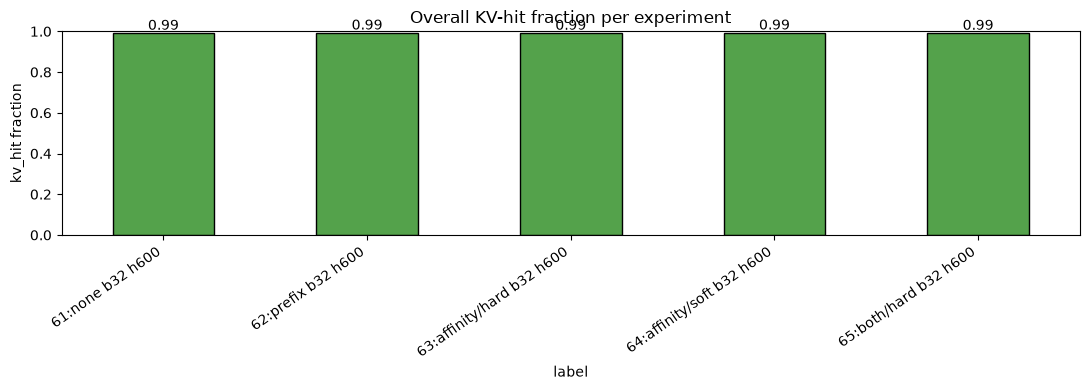

In [4]:
ok = LOGS[~LOGS["failed"] & LOGS["kv_hit"].notna()].copy()
ok["kv_hit_b"] = ok["kv_hit"].astype(bool)

kv_overall = ok.groupby("label")["kv_hit_b"].mean().rename("kv_hit_frac")
kv_by_type = ok.pivot_table(index="label", columns="turn_type",
                            values="kv_hit_b", aggfunc="mean")
kv_tbl = pd.concat([kv_overall, kv_by_type], axis=1)
kv_tbl = kv_tbl.reindex([LABELS[e] for e in EXP_IDS])
display(kv_tbl.round(4))

ax = kv_tbl[["kv_hit_frac"]].plot(kind="bar", figsize=(11, 4), legend=False,
                                  color="#54A24B", edgecolor="black")
ax.set_ylabel("kv_hit fraction"); ax.set_ylim(0, 1)
ax.set_title("Overall KV-hit fraction per experiment")
for i, v in enumerate(kv_tbl["kv_hit_frac"]):
    if pd.notna(v):
        ax.text(i, v, f"{v:.2f}", ha="center", va="bottom")
plt.xticks(rotation=35, ha="right"); plt.tight_layout(); plt.show()

### 2b. Affinity stickiness (distinct pods per conversation)

,conversations,multi_turn,sticky_frac,avg_distinct_ep,max_distinct_ep
label,,,,,
61:none b32 h600,470.0,229.0,0.2445,1.7555,2.0
62:prefix b32 h600,472.0,226.0,0.2876,1.7124,2.0
63:affinity/hard b32 h600,384.0,283.0,1.0000,1.0000,1.0
64:affinity/soft b32 h600,393.0,292.0,0.3527,1.6473,2.0
65:both/hard b32 h600,395.0,279.0,1.0000,1.0000,1.0


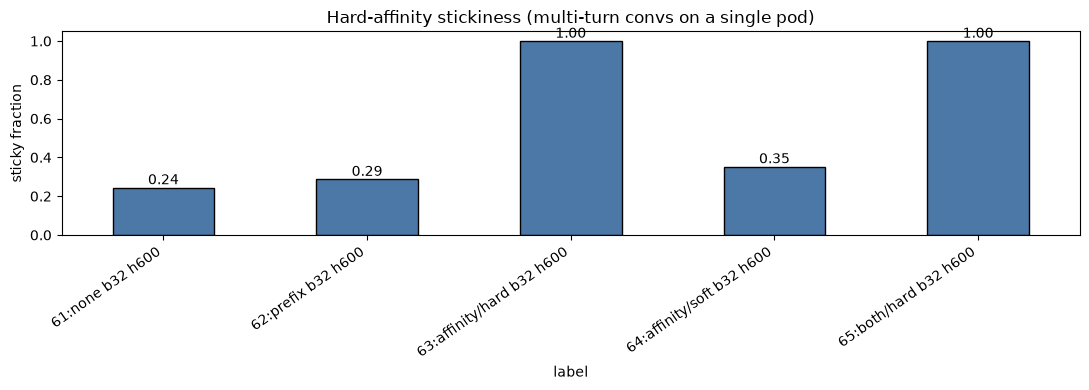

In [5]:
def stickiness(sub):
    v = sub[sub["endpoint_id"].notna()]
    per_conv = v.groupby("group")["endpoint_id"].nunique()
    req_per_conv = v.groupby("group")["req_id"].size()
    multi = per_conv[req_per_conv > 1]
    n_multi = len(multi)
    sticky = int((multi == 1).sum()) if n_multi else 0
    return pd.Series({
        "conversations": int(per_conv.size),
        "multi_turn": int(n_multi),
        "sticky_frac": round(sticky / n_multi, 4) if n_multi else np.nan,
        "avg_distinct_ep": round(float(multi.mean()), 4) if n_multi else np.nan,
        "max_distinct_ep": int(multi.max()) if n_multi else np.nan,
    })

STICK = LOGS[~LOGS["failed"]].groupby("label").apply(stickiness)
STICK = STICK.reindex([LABELS[e] for e in EXP_IDS])
display(STICK)

ax = STICK[["sticky_frac"]].plot(kind="bar", figsize=(11, 4), legend=False,
                                 color="#4C78A8", edgecolor="black")
ax.set_ylabel("sticky fraction"); ax.set_ylim(0, 1.05)
ax.set_title("Hard-affinity stickiness (multi-turn convs on a single pod)")
for i, v in enumerate(STICK["sticky_frac"]):
    if pd.notna(v):
        ax.text(i, v, f"{v:.2f}", ha="center", va="bottom")
plt.xticks(rotation=35, ha="right"); plt.tight_layout(); plt.show()

### 2c. Per-pod load balance + per-pod KV-hit

In [6]:
def per_pod(sub):
    v = sub[sub["endpoint_id"].notna() & ~sub["failed"]]
    g = v.groupby("endpoint_id").agg(
        requests=("req_id", "size"),
        conversations=("group", "nunique"),
        kv_hit_frac=("kv_hit", lambda s: pd.Series(s).dropna().astype(bool).mean()),
        matched_tokens=("matched_tokens", "sum"),
    )
    return g

for e in EXP_IDS:
    sub = LOGS[LOGS["exp"] == e]
    pp = per_pod(sub)
    if pp.empty:
        continue
    r = pp["requests"]
    imb = r.max() / r.mean() if len(r) > 1 else 1.0
    print(f"=== {LABELS[e]} | load imbalance max/mean = {imb:.2f}x ===")
    display(pp.round(4))

=== 61:none b32 h600 | load imbalance max/mean = 1.05x ===


,requests,conversations,kv_hit_frac,matched_tokens
endpoint_id,,,,
vllm-minimax-m2-0,473,330,0.9937,232960
vllm-minimax-m2-1,432,313,0.9884,210432


=== 62:prefix b32 h600 | load imbalance max/mean = 1.07x ===


,requests,conversations,kv_hit_frac,matched_tokens
endpoint_id,,,,
vllm-minimax-m2-0,483,332,0.9896,233728
vllm-minimax-m2-1,423,301,0.9953,176896


=== 63:affinity/hard b32 h600 | load imbalance max/mean = 1.01x ===


,requests,conversations,kv_hit_frac,matched_tokens
endpoint_id,,,,
vllm-minimax-m2-0,457,194,0.9912,336256
vllm-minimax-m2-1,449,190,0.9911,321920


=== 64:affinity/soft b32 h600 | load imbalance max/mean = 1.08x ===


,requests,conversations,kv_hit_frac,matched_tokens
endpoint_id,,,,
vllm-minimax-m2-0,498,312,0.9900,222464
vllm-minimax-m2-1,428,270,0.9953,209664


=== 65:both/hard b32 h600 | load imbalance max/mean = 1.01x ===


,requests,conversations,kv_hit_frac,matched_tokens
endpoint_id,,,,
vllm-minimax-m2-0,460,202,0.9935,332800
vllm-minimax-m2-1,447,193,0.9888,346240


### 2d. Latency: TTFT + end-to-end percentiles

,e2e_p50,e2e_p95,e2e_p99,e2e_max,ttft_p50,ttft_p95,ttft_p99,near_timeout,failed
label,,,,,,,,,
61:none b32 h600,119.722,496.549,728.235,842.768,1.100,1.480,1.673,0,0
62:prefix b32 h600,123.170,512.739,791.746,884.358,1.089,1.518,1.783,0,0
63:affinity/hard b32 h600,119.874,514.038,772.985,898.680,1.116,1.536,1.743,0,0
64:affinity/soft b32 h600,119.746,503.330,750.728,883.192,1.082,1.493,1.643,0,0
65:both/hard b32 h600,125.696,457.829,767.589,889.144,1.132,1.543,1.766,0,0


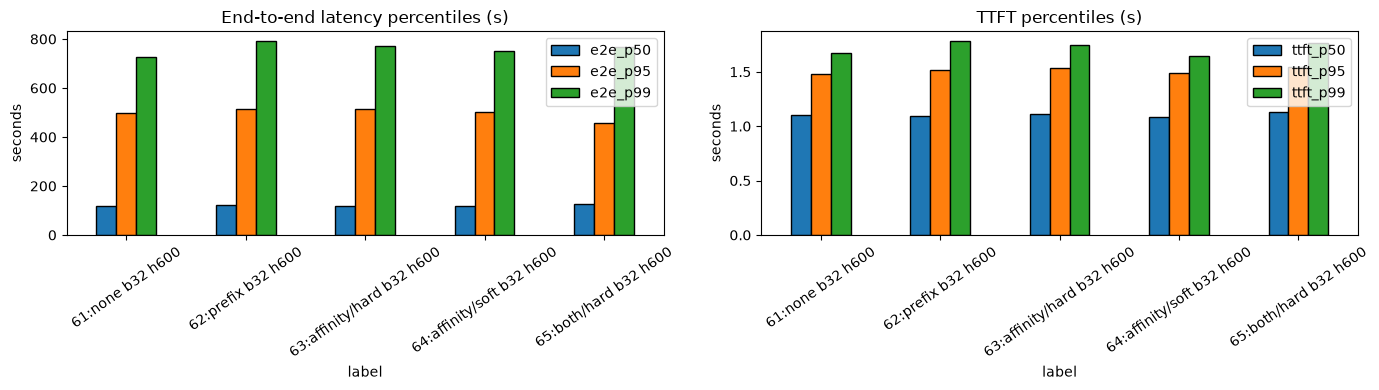

In [7]:
def pcts(s):
    s = pd.to_numeric(s, errors="coerce").dropna()
    if s.empty:
        return pd.Series({"p50": np.nan, "p95": np.nan, "p99": np.nan, "max": np.nan})
    return pd.Series({"p50": s.quantile(.50), "p95": s.quantile(.95),
                      "p99": s.quantile(.99), "max": s.max()})

good = LOGS[~LOGS["failed"]]
lat = []
for e in EXP_IDS:
    sub = good[good["exp"] == e]
    e2e = pcts(sub["end_to_end_s"]); ttft = pcts(sub["ttft_s"])
    n_to = int((pd.to_numeric(sub["end_to_end_s"], errors="coerce") >= 0.95 * RESULT_TIMEOUT_S).sum())
    n_fail = int(LOGS[(LOGS["exp"] == e)]["failed"].sum())
    lat.append({"label": LABELS[e],
                "e2e_p50": e2e["p50"], "e2e_p95": e2e["p95"], "e2e_p99": e2e["p99"], "e2e_max": e2e["max"],
                "ttft_p50": ttft["p50"], "ttft_p95": ttft["p95"], "ttft_p99": ttft["p99"],
                "near_timeout": n_to, "failed": n_fail})
LAT = pd.DataFrame(lat).set_index("label").reindex([LABELS[e] for e in EXP_IDS])
display(LAT.round(3))

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
LAT[["e2e_p50", "e2e_p95", "e2e_p99"]].plot(kind="bar", ax=ax[0], edgecolor="black")
ax[0].set_title("End-to-end latency percentiles (s)"); ax[0].set_ylabel("seconds")
ax[0].tick_params(axis="x", rotation=35)
LAT[["ttft_p50", "ttft_p95", "ttft_p99"]].plot(kind="bar", ax=ax[1], edgecolor="black")
ax[1].set_title("TTFT percentiles (s)"); ax[1].set_ylabel("seconds")
ax[1].tick_params(axis="x", rotation=35)
plt.tight_layout(); plt.show()

### 2e. TTFT by turn index (does reuse pay off?)

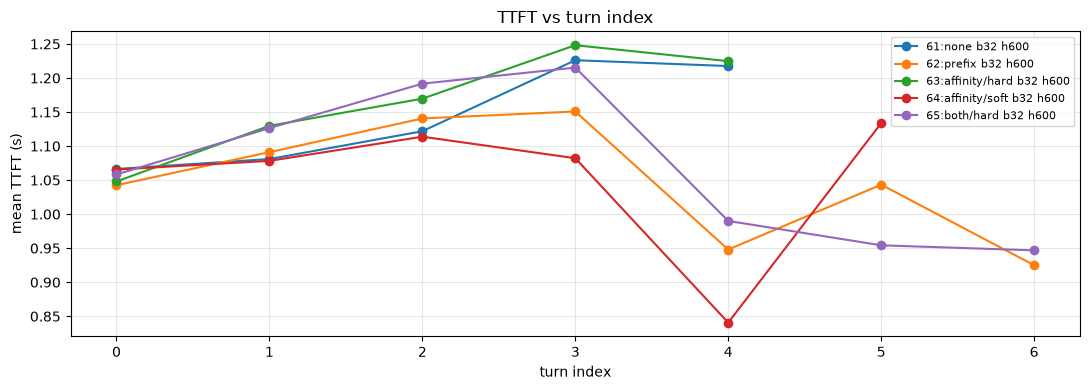

In [8]:
fig, ax = plt.subplots(figsize=(11, 4))
for e in EXP_IDS:
    sub = good[(good["exp"] == e) & good["ttft_s"].notna()]
    if sub.empty:
        continue
    by_turn = sub.groupby("turn_idx")["ttft_s"].mean()
    ax.plot(by_turn.index, by_turn.values, marker="o", label=LABELS[e])
ax.set_xlabel("turn index"); ax.set_ylabel("mean TTFT (s)")
ax.set_title("TTFT vs turn index"); ax.legend(fontsize=8); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

### 2f. Prefix-reuse payoff: matched_tokens / kv_hits_len / claude cache_read

,matched_tokens_mean,kv_hits_len_mean,cache_read_mean,cache_read_sum
label,,,,
61:none b32 h600,489.94,3.83,0.0,0.0
62:prefix b32 h600,453.23,3.54,0.0,0.0
63:affinity/hard b32 h600,726.46,5.68,0.0,0.0
64:affinity/soft b32 h600,466.66,3.65,0.0,0.0
65:both/hard b32 h600,748.67,5.85,0.0,0.0


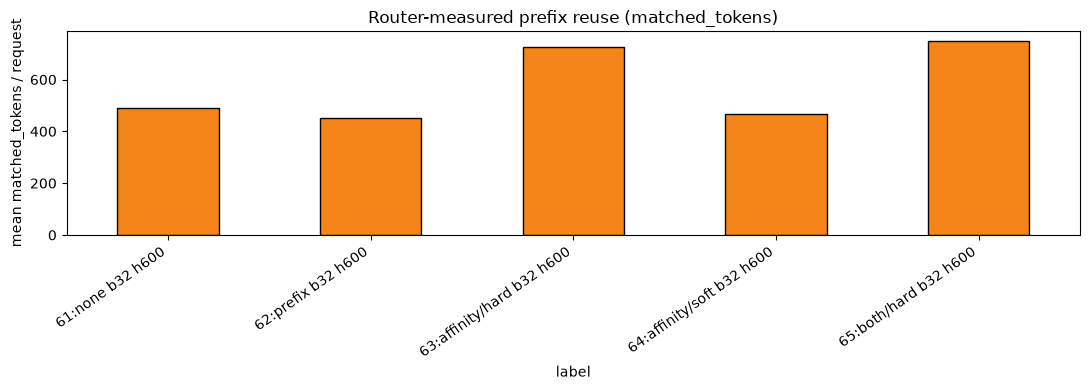

In [9]:
reuse = good.groupby("label").agg(
    matched_tokens_mean=("matched_tokens", "mean"),
    kv_hits_len_mean=("kv_hits_len", "mean"),
    cache_read_mean=("cache_read_input_tokens", "mean"),
    cache_read_sum=("cache_read_input_tokens", "sum"),
).reindex([LABELS[e] for e in EXP_IDS])
display(reuse.round(2))

ax = reuse[["matched_tokens_mean"]].plot(kind="bar", figsize=(11, 4), legend=False,
                                         color="#F58518", edgecolor="black")
ax.set_ylabel("mean matched_tokens / request")
ax.set_title("Router-measured prefix reuse (matched_tokens)")
plt.xticks(rotation=35, ha="right"); plt.tight_layout(); plt.show()

## 3. Metrics analysis (fleet)

`metrics_summary.json` rollups, then the `metrics.jsonl` time series aligned to elapsed seconds.

In [10]:
ms_rows = []
for e in EXP_IDS:
    ms = _read_json(exp_dir(e) / "metrics_summary.json")
    ov = (ms or {}).get("overall", {}) if ms else {}
    ov = dict(ov); ov["label"] = LABELS[e]; ov["samples"] = (ms or {}).get("samples")
    ms_rows.append(ov)
MS = pd.DataFrame(ms_rows).set_index("label").reindex([LABELS[e] for e in EXP_IDS])
cols = [c for c in [
    "avg_ttft_seconds", "avg_e2e_latency_seconds", "avg_tpot_seconds",
    "avg_kv_cache_usage_perc", "avg_prefix_cache_hit_rate",
    "avg_requests_running", "avg_requests_waiting", "avg_queue_time_seconds",
    "avg_router_queue_length", "sum_generation_tokens_per_sec",
    "sum_prefill_tokens_per_sec", "sum_router_admission_rps",
] if c in MS.columns]
display(MS[cols].round(4))

,avg_ttft_seconds,avg_e2e_latency_seconds,avg_tpot_seconds,avg_kv_cache_usage_perc,avg_prefix_cache_hit_rate,avg_requests_running,avg_requests_waiting,avg_queue_time_seconds,avg_router_queue_length,sum_generation_tokens_per_sec,sum_prefill_tokens_per_sec,sum_router_admission_rps
label,,,,,,,,,,,,
61:none b32 h600,0.6131,104.0869,None,0.0433,0.3174,6.9674,0.0,0.0,0.0214,359.4400,219.0176,0.8615
62:prefix b32 h600,0.6067,103.8055,None,0.0376,0.3015,6.6627,0.0,0.0,0.0167,353.2098,240.3373,0.8485
63:affinity/hard b32 h600,0.6164,103.8688,None,0.0426,0.3793,6.7581,0.0,0.0,0.0240,352.0356,264.0032,0.8105
64:affinity/soft b32 h600,0.6095,93.1871,None,0.0407,0.3172,6.9713,0.0,0.0,0.0200,368.8298,282.5543,0.9094
65:both/hard b32 h600,0.6030,94.9583,None,0.0377,0.3940,6.9968,0.0,0.0,0.0308,376.5271,267.1504,0.9259


In [11]:
def load_metrics_ts(exp_id):
    rows = _read_ndjson(exp_dir(exp_id) / "metrics.jsonl")
    out = []
    for r in rows:
        ts = r.get("ts")
        for s in (r.get("samples") or []):
            pod = s.get("pod") or s.get("instance")
            out.append({
                "ts": ts, "pod": pod,
                "requests_running": s.get("requests_running"),
                "requests_waiting": s.get("requests_waiting"),
                "kv_cache_usage_perc": s.get("kv_cache_usage_perc"),
                "prefix_cache_hit_rate": s.get("prefix_cache_hit_rate"),
                "gen_tokens_per_sec": s.get("gen_tokens_per_sec"),
                "prefill_tokens_per_sec": s.get("prefill_tokens_per_sec"),
                "router_queue_length": s.get("router_queue_length"),
                "router_admission_rps": s.get("router_admission_rps"),
            })
    df = pd.DataFrame(out)
    if df.empty:
        return df
    df["ts"] = pd.to_datetime(df["ts"], errors="coerce", utc=True)
    df = df.dropna(subset=["ts"])
    t0 = df["ts"].min()
    df["t_s"] = (df["ts"] - t0).dt.total_seconds()
    df["exp"] = exp_id; df["label"] = LABELS[exp_id]
    return df

TS = {e: load_metrics_ts(e) for e in EXP_IDS}
def fleet_series(df, col, agg="sum"):
    if df.empty or col not in df.columns:
        return pd.Series(dtype=float)
    g = df.groupby("ts")[col]
    fleet = g.sum() if agg == "sum" else g.mean()
    tt = df.groupby("ts")["t_s"].first()
    s = pd.DataFrame({"t_s": tt, "v": fleet}).dropna()
    s["bin"] = (s["t_s"] // 5 * 5).astype(int)
    return s.groupby("bin")["v"].mean()
print("metrics ticks per exp:", {e: (0 if TS[e].empty else TS[e]['ts'].nunique()) for e in EXP_IDS})

metrics ticks per exp: {61: 2622, 62: 2689, 63: 2797, 64: 2547, 65: 2465}


### 3a. Backpressure signals: running / waiting / queue / KV-cache usage

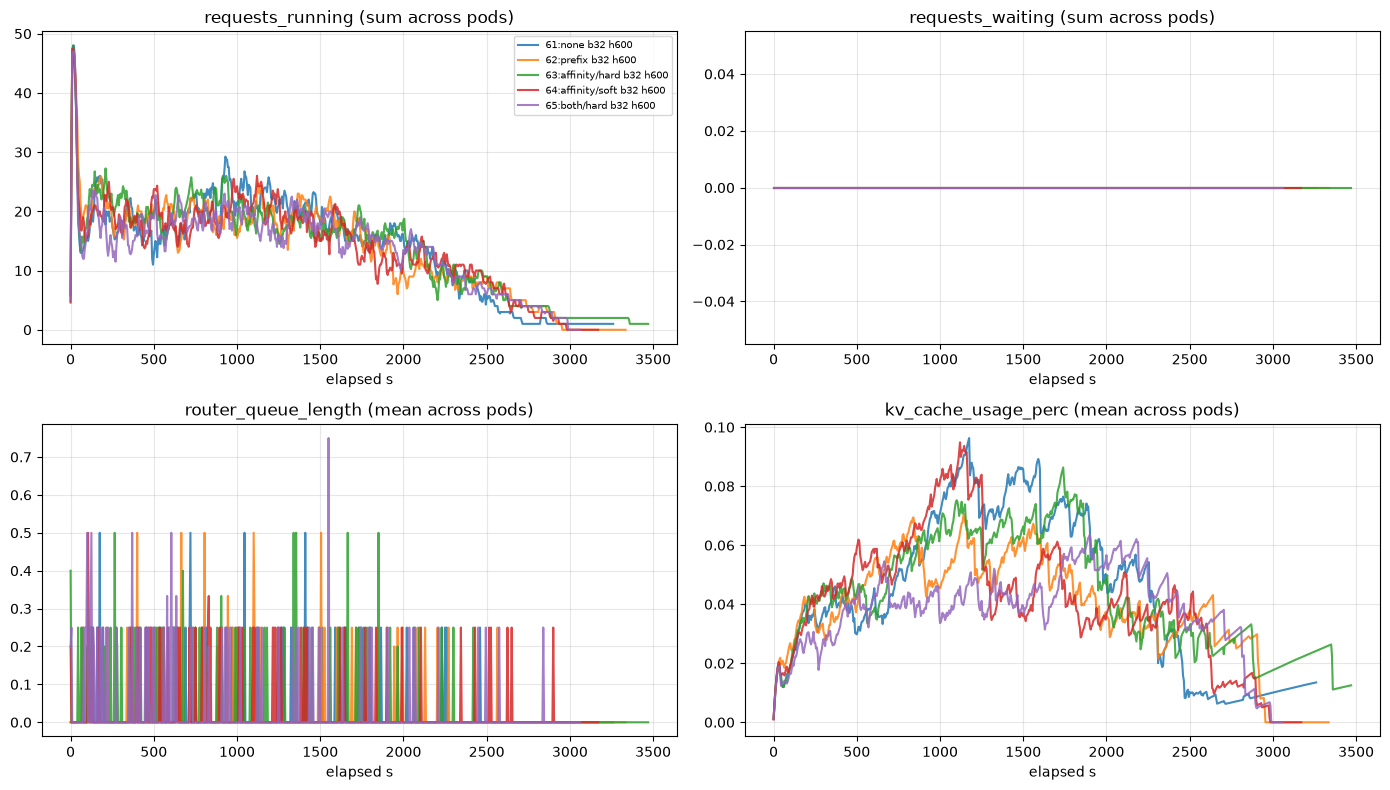

In [12]:
panels = [("requests_running", "sum"), ("requests_waiting", "sum"),
          ("router_queue_length", "mean"), ("kv_cache_usage_perc", "mean")]
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, (col, agg) in zip(axes.ravel(), panels):
    for e in EXP_IDS:
        s = fleet_series(TS[e], col, agg)
        if not s.empty:
            ax.plot(s.index, s.values, label=LABELS[e], alpha=.85)
    ax.set_title(f"{col} ({agg} across pods)")
    ax.set_xlabel("elapsed s"); ax.grid(alpha=.3)
axes.ravel()[0].legend(fontsize=7)
plt.tight_layout(); plt.show()

### 3b. Throughput + engine realized prefix-cache hit rate

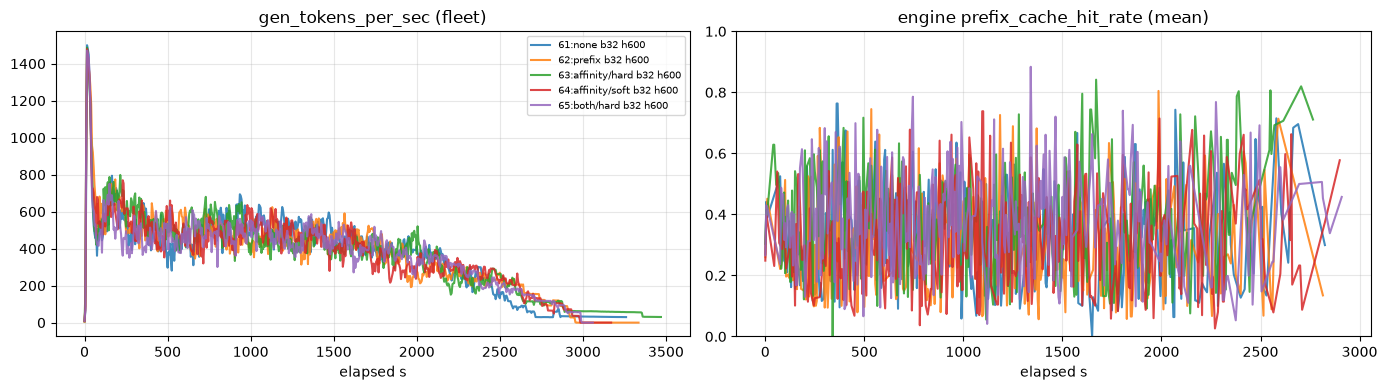

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
for e in EXP_IDS:
    s = fleet_series(TS[e], "gen_tokens_per_sec", "sum")
    if not s.empty:
        ax[0].plot(s.index, s.values, label=LABELS[e], alpha=.85)
ax[0].set_title("gen_tokens_per_sec (fleet)"); ax[0].set_xlabel("elapsed s"); ax[0].grid(alpha=.3)
ax[0].legend(fontsize=7)
for e in EXP_IDS:
    s = fleet_series(TS[e], "prefix_cache_hit_rate", "mean")
    if not s.empty:
        ax[1].plot(s.index, s.values, label=LABELS[e], alpha=.85)
ax[1].set_title("engine prefix_cache_hit_rate (mean)"); ax[1].set_xlabel("elapsed s")
ax[1].set_ylim(0, 1); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

## 4. Redis KV-block ownership + verification

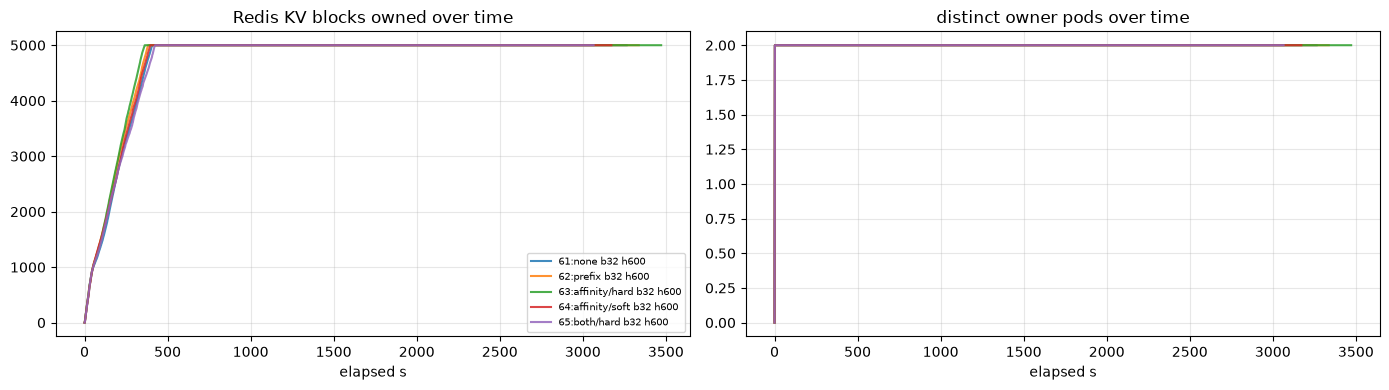

,checked,hashes_match,missing,records_with_hashes,peak_kv_blocks
label,,,,,
61:none b32 h600,None,None,None,None,5000
62:prefix b32 h600,None,None,None,None,5000
63:affinity/hard b32 h600,None,None,None,None,5000
64:affinity/soft b32 h600,None,None,None,None,5000
65:both/hard b32 h600,None,None,None,None,5000


In [14]:
def load_kvwatch(exp_id):
    rows = _read_ndjson(exp_dir(exp_id) / "redis_kv_watch.jsonl")
    if not rows:
        return pd.DataFrame()
    df = pd.DataFrame(rows)
    df["exp"] = exp_id; df["label"] = LABELS[exp_id]
    if "ts" in df.columns:
        df["t_s"] = df["ts"] - df["ts"].min()
    kb = "kv_blocks" if "kv_blocks" in df.columns else ("keys" if "keys" in df.columns else None)
    df["kv_blocks_"] = df[kb] if kb else np.nan
    return df

KVW = {e: load_kvwatch(e) for e in EXP_IDS}

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
for e in EXP_IDS:
    d = KVW[e]
    if d.empty or "t_s" not in d.columns:
        continue
    ax[0].plot(d["t_s"], d["kv_blocks_"], label=LABELS[e], alpha=.85)
    if "unique_owners" in d.columns:
        ax[1].plot(d["t_s"], d["unique_owners"], label=LABELS[e], alpha=.85)
ax[0].set_title("Redis KV blocks owned over time"); ax[0].set_xlabel("elapsed s"); ax[0].grid(alpha=.3)
ax[0].legend(fontsize=7)
ax[1].set_title("distinct owner pods over time"); ax[1].set_xlabel("elapsed s"); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

ver = []
for e in EXP_IDS:
    v = _read_json(exp_dir(e) / "redis_verify.json") or {}
    ver.append({"label": LABELS[e], "checked": v.get("checked"),
                "hashes_match": v.get("hashes_match"), "missing": v.get("missing"),
                "records_with_hashes": v.get("records_with_hashes"),
                "peak_kv_blocks": (None if KVW[e].empty else (int(np.nanmax(KVW[e]["kv_blocks_"]))
                                   if KVW[e]["kv_blocks_"].notna().any() else None))})
display(pd.DataFrame(ver).set_index("label").reindex([LABELS[e] for e in EXP_IDS]))

## 5. Head-to-head summary

In [15]:
summary = REG[["strategy", "mode", "hold_s", "batch"]].copy()
summary["label"] = [LABELS[e] for e in summary.index]
summary = summary.set_index("label")

def _get(df, label, col):
    try:
        return df.loc[label, col]
    except Exception:
        return np.nan

for e in EXP_IDS:
    lab = LABELS[e]
    summary.loc[lab, "kv_hit_frac"] = _get(kv_tbl, lab, "kv_hit_frac")
    summary.loc[lab, "kv_hit_repeat"] = _get(kv_tbl, lab, "repeat") if "repeat" in kv_tbl.columns else np.nan
    summary.loc[lab, "sticky_frac"] = _get(STICK, lab, "sticky_frac")
    summary.loc[lab, "avg_distinct_ep"] = _get(STICK, lab, "avg_distinct_ep")
    summary.loc[lab, "e2e_p50"] = _get(LAT, lab, "e2e_p50")
    summary.loc[lab, "e2e_p99"] = _get(LAT, lab, "e2e_p99")
    summary.loc[lab, "ttft_p50"] = _get(LAT, lab, "ttft_p50")
    summary.loc[lab, "near_timeout"] = _get(LAT, lab, "near_timeout")
    summary.loc[lab, "failed"] = _get(LAT, lab, "failed")
    summary.loc[lab, "avg_req_waiting"] = _get(MS, lab, "avg_requests_waiting")
    summary.loc[lab, "avg_kv_usage"] = _get(MS, lab, "avg_kv_cache_usage_perc")
    summary.loc[lab, "gen_tok_s"] = _get(MS, lab, "sum_generation_tokens_per_sec")

summary = summary.reindex([LABELS[e] for e in EXP_IDS])
display(summary.round(4))

,strategy,mode,hold_s,batch,kv_hit_frac,kv_hit_repeat,sticky_frac,avg_distinct_ep,e2e_p50,e2e_p99,ttft_p50,near_timeout,failed,avg_req_waiting,avg_kv_usage,gen_tok_s
label,,,,,,,,,,,,,,,,
61:none b32 h600,none,hard,600,32,0.9912,1.0,0.2445,1.7555,119.7219,728.2350,1.1000,0.0,0.0,0.0,0.0433,359.4400
62:prefix b32 h600,prefix,hard,600,32,0.9923,1.0,0.2876,1.7124,123.1695,791.7459,1.0895,0.0,0.0,0.0,0.0376,353.2098
63:affinity/hard b32 h600,affinity,hard,600,32,0.9912,1.0,1.0000,1.0000,119.8735,772.9851,1.1160,0.0,0.0,0.0,0.0426,352.0356
64:affinity/soft b32 h600,affinity,soft,600,32,0.9924,1.0,0.3527,1.6473,119.7461,750.7280,1.0822,0.0,0.0,0.0,0.0407,368.8298
65:both/hard b32 h600,both,hard,600,32,0.9912,1.0,1.0000,1.0000,125.6962,767.5891,1.1318,0.0,0.0,0.0,0.0377,376.5271


### What to look for
- **Best strategy** = highest `kv_hit_frac` (esp. `repeat` turns) and `sticky_frac` ~ 1.0 with balanced per-pod load and no latency penalty.
- `none`/`prefix` have no affinity, so expect lower stickiness; `affinity`/`both` hard should pin conversations (sticky ~ 1.0).
- `soft` (57) vs `hard` (56): soft is preference-only, so it may leak conversations across pods (stickiness < 1.0) and lose repeat-turn hits.
- `both` (58) adds KV-overlap ordering on top of affinity; compare its repeat-turn KV-hit vs plain `affinity` (56).